# RELATÓRIO TÉCNICO-CIENTÍFICO DE CALIBRAÇÃO EMPÍRICA
## Engenharia de Programa 2026.2 / Prof. Diego Frias
### Paradigma F.O.C.A. — 4.3. Custo de Operações Matemáticas (τo)
**Responsável: Aluno 3**

**Objetivo:** Executar a medição empírica direta in-line, filtragem estatística de outliers por percentil (cortando 5% e 95%) e homologação dos custos de tempo (τo) para primitivas matemáticas em inteiros e ponto flutuante, garantindo a estabilidade (CV < 0.15).

**Painel Gráfico de Estabilidade (Seção 3):** Exatamente 3 gráficos consolidados contendo todas as operações matemáticas sobrepostas por cores.

In [1]:
# ==============================================================================
# 1. SETUP DO AMBIENTE E VARIÁVEIS RESIDENTES
# ==============================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Hiperparâmetros metodológicos
N = 500_000   # Tamanho da amostra interna (número de operações por repetição)
R = 40        # Número de repetições globais

# Setup de variáveis e constantes residentes em memória
v_int1 = 42
v_int2 = 17
v_flt1 = 3.14159
v_flt2 = 2.71828
c_int = 10
c_flt = 1.41421

# Warmup inicial do processador para estabilização de clock e cache
for _ in range(100_000):
    _ = (1 + 1)

print("Ambiente inicializado e aquecido com sucesso!")


Ambiente inicializado e aquecido com sucesso!


In [2]:
# ==============================================================================
# 2. MEDIÇÃO DIRETA IN-LINE (SEM FUNÇÕES INTERMEDIÁRIAS) DAS 9 OPERAÇÕES
# ==============================================================================

tempos_brutos = {}
tempos_filtrados = {}
cortes_percentil = {}
tabela_resultados = []
reps = np.arange(1, R + 1)

def processar_estatisticas(nome_op, times_list):
    raw = np.array(times_list)
    tempos_brutos[nome_op] = raw
    
    mu_b = np.mean(raw)
    sigma_b = np.std(raw, ddof=1)
    cv_b = sigma_b / mu_b
    
    # Filtro de Percentil 5% e 95%
    p5 = np.percentile(raw, 5)
    p95 = np.percentile(raw, 95)
    cortes_percentil[nome_op] = (p5, p95)
    
    fil = raw[(raw >= p5) & (raw <= p95)]
    tempos_filtrados[nome_op] = fil
    
    mu_f = np.mean(fil)
    sigma_f = np.std(fil, ddof=1)
    cv_f = sigma_f / mu_f
    
    tabela_resultados.append({
        "Operação e Tipagem Exata": nome_op,
        "µbruta (s)": f"{mu_b:.4e}",
        "σbruta (s)": f"{sigma_b:.4e}",
        "CVbruto": f"{cv_b:.4f}",
        "µfil(τo) (s)": f"{mu_f:.4e}",
        "σfil (s)": f"{sigma_f:.4e}",
        "CVfil": f"{cv_f:.4f}",
        "< 0.15": "Sim" if cv_f < 0.15 else "Não"
    })

print("Executando calibração de operações matemáticas (τo)...")

# 1. Soma Int: var int + cte int
t_op1 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 + 10
    t1 = time.perf_counter()
    t_op1.append((t1 - t0) / N)
processar_estatisticas("Soma Int: var int + cte int", t_op1)
print("  [1/9] Concluído: Soma Int: var int + cte int")

# 2. Soma Int: var int + var int
t_op2 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 + v_int2
    t1 = time.perf_counter()
    t_op2.append((t1 - t0) / N)
processar_estatisticas("Soma Int: var int + var int", t_op2)
print("  [2/9] Concluído: Soma Int: var int + var int")

# 3. Soma Float: var float + var float
t_op3 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt1 + v_flt2
    t1 = time.perf_counter()
    t_op3.append((t1 - t0) / N)
processar_estatisticas("Soma Float: var float + var float", t_op3)
print("  [3/9] Concluído: Soma Float: var float + var float")

# 4. Subtração Int: var int - var int
t_op4 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 - v_int2
    t1 = time.perf_counter()
    t_op4.append((t1 - t0) / N)
processar_estatisticas("Subtração Int: var int - var int", t_op4)
print("  [4/9] Concluído: Subtração Int: var int - var int")

# 5. Multiplicação Int: var int * var int
t_op5 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 * v_int2
    t1 = time.perf_counter()
    t_op5.append((t1 - t0) / N)
processar_estatisticas("Multiplicação Int: var int * var int", t_op5)
print("  [5/9] Concluído: Multiplicação Int: var int * var int")

# 6. Mult. Float: var float * var float
t_op6 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt1 * v_flt2
    t1 = time.perf_counter()
    t_op6.append((t1 - t0) / N)
processar_estatisticas("Mult. Float: var float * var float", t_op6)
print("  [6/9] Concluído: Mult. Float: var float * var float")

# 7. Divisão Float: var float / var float
t_op7 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_flt1 / v_flt2
    t1 = time.perf_counter()
    t_op7.append((t1 - t0) / N)
processar_estatisticas("Divisão Float: var float / var float", t_op7)
print("  [7/9] Concluído: Divisão Float: var float / var float")

# 8. Divisão Int (Piso): var int // var int
t_op8 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 // v_int2
    t1 = time.perf_counter()
    t_op8.append((t1 - t0) / N)
processar_estatisticas("Divisão Int (Piso): var int // var int", t_op8)
print("  [8/9] Concluído: Divisão Int (Piso): var int // var int")

# 9. Módulo (Resto): var int % var int
t_op9 = []
for r in range(R):
    t0 = time.perf_counter()
    for _ in range(N):
        v_int1 % v_int2
    t1 = time.perf_counter()
    t_op9.append((t1 - t0) / N)
processar_estatisticas("Módulo (Resto): var int % var int", t_op9)
print("  [9/9] Concluído: Módulo (Resto): var int % var int")

print("\nTodas as 9 medições concluídas!")


Executando calibração de operações matemáticas (τo)...
  [1/9] Concluído: Soma Int: var int + cte int
  [2/9] Concluído: Soma Int: var int + var int
  [3/9] Concluído: Soma Float: var float + var float
  [4/9] Concluído: Subtração Int: var int - var int
  [5/9] Concluído: Multiplicação Int: var int * var int
  [6/9] Concluído: Mult. Float: var float * var float
  [7/9] Concluído: Divisão Float: var float / var float
  [8/9] Concluído: Divisão Int (Piso): var int // var int
  [9/9] Concluído: Módulo (Resto): var int % var int

Todas as 9 medições concluídas!


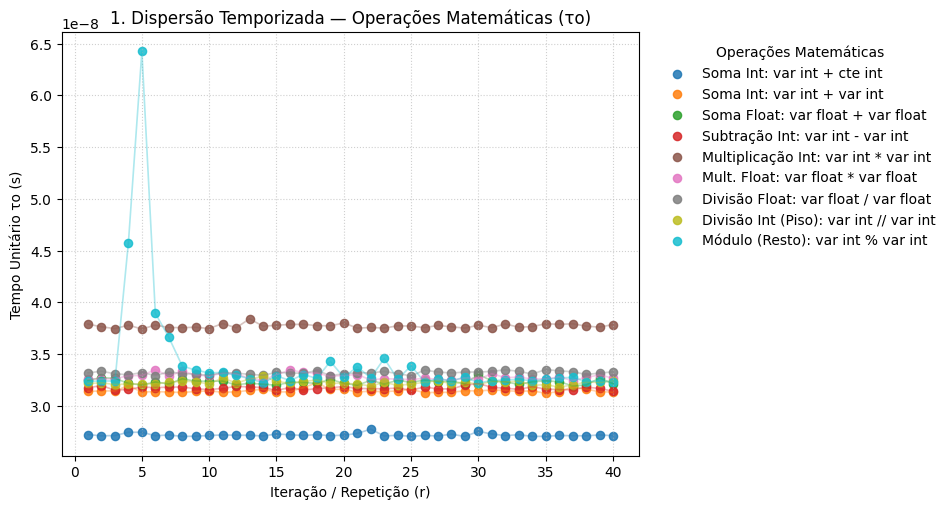

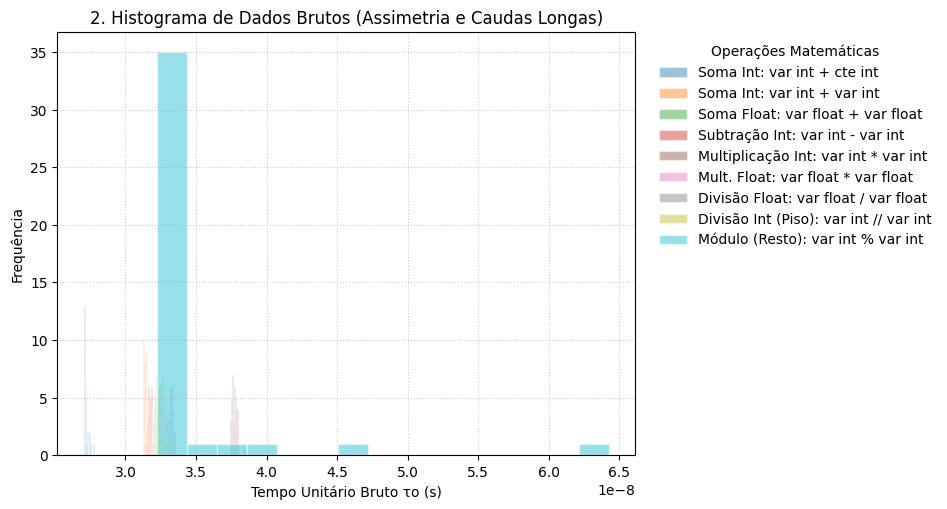

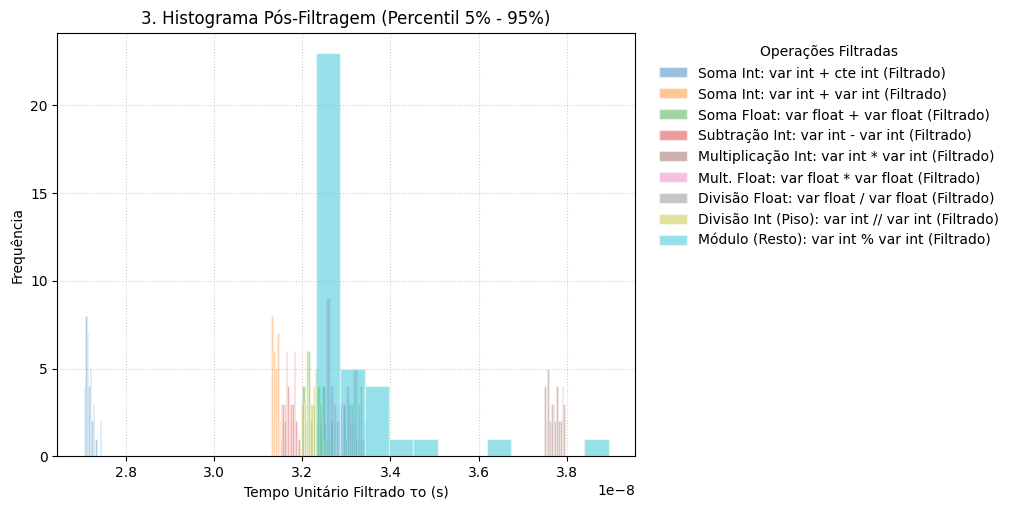

In [3]:
# ==============================================================================
# 3. PAINEL DE 3 GRÁFICOS CONSOLIDADOS (SEÇÃO 3 DO RELATÓRIO)
# ==============================================================================
# Exatamente 3 gráficos com todas as operações matemáticas sobrepostas por cores

nomes_ops = list(tempos_brutos.keys())
cores_op = {nome: cor for nome, cor in zip(nomes_ops, plt.cm.tab10(np.linspace(0, 1, len(nomes_ops))))}

# ------------------------------------------------------------------------------
# 1) Gráfico de Dispersão Temporizada (r vs Tempo)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.scatter(reps, tempos_brutos[nome], color=cores_op[nome], label=nome, alpha=0.85, s=35)
    ax.plot(reps, tempos_brutos[nome], color=cores_op[nome], alpha=0.35, lw=1.2)

ax.set_xlabel("Iteração / Repetição (r)")
ax.set_ylabel("Tempo Unitário τo (s)")
ax.set_title("1. Dispersão Temporizada — Operações Matemáticas (τo)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Operações Matemáticas")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.65)
plt.show()

# ------------------------------------------------------------------------------
# 2) Histograma de Dados Brutos (Distribuição Sobreposta)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.hist(tempos_brutos[nome], bins=15, alpha=0.45, color=cores_op[nome], label=nome, edgecolor="white")

ax.set_xlabel("Tempo Unitário Bruto τo (s)")
ax.set_ylabel("Frequência")
ax.set_title("2. Histograma de Dados Brutos (Assimetria e Caudas Longas)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Operações Matemáticas")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.65)
plt.show()

# ------------------------------------------------------------------------------
# 3) Histograma Pós-Filtragem (Percentil 5% e 95%)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.5))
for nome in nomes_ops:
    ax.hist(tempos_filtrados[nome], bins=12, alpha=0.45, color=cores_op[nome], label=f"{nome} (Filtrado)", edgecolor="white")

ax.set_xlabel("Tempo Unitário Filtrado τo (s)")
ax.set_ylabel("Frequência")
ax.set_title("3. Histograma Pós-Filtragem (Percentil 5% - 95%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Operações Filtradas")
ax.grid(True, linestyle=":", alpha=0.6)
fig.subplots_adjust(right=0.65)
plt.show()


In [4]:
# ==============================================================================
# 4. MATRIZ FINAL DE CALIBRAÇÃO HOMOLOGADA (τo) - TABELA 4.3
# ==============================================================================

# Configura o pandas para exibir todas as colunas sem quebra de linhas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

df_tau_o = pd.DataFrame(tabela_resultados)

print("\n" + "="*80)
print("4.3. CUSTO DE OPERAÇÕES MATEMÁTICAS (τo) - HOMOLOGAÇÃO (CV < 0.15)")
print("="*80)

# 1. Exibição garantida em texto plano (sem quebra)
print(df_tau_o.to_string(index=False))

# 2. Renderização interativa de tabela do Jupyter/VS Code
df_tau_o



4.3. CUSTO DE OPERAÇÕES MATEMÁTICAS (τo) - HOMOLOGAÇÃO (CV < 0.15)
              Operação e Tipagem Exata µbruta (s) σbruta (s) CVbruto µfil(τo) (s)   σfil (s)  CVfil < 0.15
           Soma Int: var int + cte int 2.7188e-08 1.4458e-10  0.0053   2.7171e-08 9.6285e-11 0.0035    Sim
           Soma Int: var int + var int 3.1466e-08 1.9387e-10  0.0062   3.1444e-08 1.2524e-10 0.0040    Sim
     Soma Float: var float + var float 3.2311e-08 2.3769e-10  0.0074   3.2298e-08 1.8803e-10 0.0058    Sim
      Subtração Int: var int - var int 3.1716e-08 1.4984e-10  0.0047   3.1710e-08 1.1416e-10 0.0036    Sim
  Multiplicação Int: var int * var int 3.7721e-08 1.9324e-10  0.0051   3.7709e-08 1.4476e-10 0.0038    Sim
    Mult. Float: var float * var float 3.2825e-08 2.7729e-10  0.0084   3.2810e-08 2.2979e-10 0.0070    Sim
  Divisão Float: var float / var float 3.3191e-08 1.5604e-10  0.0047   3.3190e-08 1.3138e-10 0.0040    Sim
Divisão Int (Piso): var int // var int 3.2239e-08 2.0389e-10  0.0063   3.223

,Operação e Tipagem Exata,µbruta (s),σbruta (s),CVbruto,µfil(τo) (s),σfil (s),CVfil,< 0.15
0,Soma Int: var int + cte int,2.7188e-08,1.4458e-10,0.0053,2.7171e-08,9.6285e-11,0.0035,Sim
1,Soma Int: var int + var int,3.1466e-08,1.9387e-10,0.0062,3.1444e-08,1.2524e-10,0.0040,Sim
2,Soma Float: var float + var float,3.2311e-08,2.3769e-10,0.0074,3.2298e-08,1.8803e-10,0.0058,Sim
3,Subtração Int: var int - var int,3.1716e-08,1.4984e-10,0.0047,3.1710e-08,1.1416e-10,0.0036,Sim
4,Multiplicação Int: var int * var int,3.7721e-08,1.9324e-10,0.0051,3.7709e-08,1.4476e-10,0.0038,Sim
5,Mult. Float: var float * var float,3.2825e-08,2.7729e-10,0.0084,3.2810e-08,2.2979e-10,0.0070,Sim
6,Divisão Float: var float / var float,3.3191e-08,1.5604e-10,0.0047,3.3190e-08,1.3138e-10,0.0040,Sim
7,Divisão Int (Piso): var int // var int,3.2239e-08,2.0389e-10,0.0063,3.2230e-08,1.4697e-10,0.0046,Sim
8,Módulo (Resto): var int % var int,3.4181e-08,5.4199e-09,0.1586,3.3133e-08,1.3103e-09,0.0395,Sim


In [ ]:
# ==============================================================================
# 5. (OPCIONAL) PAINEL 1x3 PARA UMA OPERAÇÃO ESPECÍFICA
# ==============================================================================

def plot_painel_individual(nome_op):
    raw = tempos_brutos[nome_op]
    fil = tempos_filtrados[nome_op]
    p5, p95 = cortes_percentil[nome_op]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    fig.suptitle(f"Painel Individual de Estabilidade — {nome_op}", fontsize=13, fontweight="bold")
    
    # 1. Dispersão Temporizada
    axes[0].scatter(reps, raw, color="#3B6BB5", s=35, alpha=0.85, edgecolor="white")
    axes[0].plot(reps, raw, color="#3B6BB5", alpha=0.35, lw=1.2)
    axes[0].set_xlabel("Iteração / Repetição (r)")
    axes[0].set_ylabel("Tempo Unitário τo (s)")
    axes[0].set_title("1. Dispersão Temporizada (Picos SO/GC)")
    axes[0].grid(True, linestyle=":", alpha=0.6)
    
    # 2. Histograma de Dados Brutos
    axes[1].hist(raw, bins=12, color="#6B6B6B", edgecolor="white", alpha=0.8)
    axes[1].set_xlabel("Tempo Bruto τo (s)")
    axes[1].set_ylabel("Frequência")
    axes[1].set_title("2. Histograma Bruto (Assimetria / Cauda Longa)")
    axes[1].grid(True, linestyle=":", alpha=0.6)
    
    # 3. Histograma Pós-Filtragem
    axes[2].hist(fil, bins=10, color="#C1553B", edgecolor="white", alpha=0.8, label="Filtrado (5%-95%)")
    axes[2].axvline(p5, color="black", ls="--", lw=1.3, label=f"Corte P5% ({p5:.2e}s)")
    axes[2].axvline(p95, color="darkred", ls=":", lw=1.3, label=f"Corte P95% ({p95:.2e}s)")
    axes[2].set_xlabel("Tempo Filtrado τo (s)")
    axes[2].set_ylabel("Frequência")
    axes[2].set_title("3. Histograma Pós-Filtragem (Normalidade)")
    axes[2].legend(frameon=False, fontsize=9)
    axes[2].grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Exemplo de uso individual (descomente para usar):
# plot_painel_individual("Divisão Float: var float / var float")
